# Lecture Whatever

In [12]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Information

Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it,
and counting the number of rings through a microscope.  Other measurements, which are easier to obtain, are
used to predict the age.  Further information, such as weather patterns
and location (hence food availability) may be required to solve the problem.

Warwick J Nash, Tracy L Sellers, Simon R Talbot, Andrew J Cawthorn and
Wes B Ford (1994) "The Population Biology of Abalone (_Haliotis_
species) in Tasmania. I. Blacklip Abalone (_H. rubra_) from the North
Coast and Islands of Bass Strait", Sea Fisheries Division, Technical
Report No. 48 (ISSN 1034-3288)

Sources:

   (a) Original owners of database:
	Marine Resources Division
	Marine Research Laboratories - Taroona
	Department of Primary Industry and Fisheries, Tasmania
	GPO Box 619F, Hobart, Tasmania 7001, Australia
	(contact: Warwick Nash +61 02 277277, wnash@dpi.tas.gov.au)

   (b) Donor of database:
	Sam Waugh (Sam.Waugh@cs.utas.edu.au)
	Department of Computer Science, University of Tasmania
	GPO Box 252C, Hobart, Tasmania 7001, Australia

   (c) Date received: December 1995

About the dataset:
    Number of Instances: 4177
    Number of Attributes: 8

	Name		Data Type	Meas.	Description
	----		---------	-----	-----------
	Sex		nominal			M, F, and I (infant)
	Length		continuous	mm	Longest shell measurement
	Diameter	continuous	mm	perpendicular to length
	Height		continuous	mm	with meat in shell
	Whole weight	continuous	grams	whole abalone
	Shucked weight	continuous	grams	weight of meat
	Viscera weight	continuous	grams	gut weight (after bleeding)
	Shell weight	continuous	grams	after being dried
	Rings		integer			+1.5 gives the age in years


In [5]:
dataset = pd.read_csv(
    '/Users/dybl4375/Documents/Teaching/GEOL 599 - Machine Learning/Machine_Learning_Course_Code_and_Data/Data/abalone.csv',
    header=None,
    names=["sex", "length", "diameter", "height", "whole_weight", "shucked_weight", "viscera_weight", "shell_weight", "rings"]
)
dataset

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [6]:
dataset.describe()

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [8]:
# Create copy of dataset
df = dataset.copy()

# Convert categorical variable into dummy/indicator variables
df = pd.get_dummies(df, columns=["sex"], drop_first=True)
df

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings,sex_I,sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7,True,False
...,...,...,...,...,...,...,...,...,...,...
4172,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11,False,False
4173,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10,False,True
4174,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9,False,True
4175,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10,False,False


In [9]:
# Separate predictors and target
X = df.drop(columns=["rings"])
y = df["rings"]

In [14]:
# Model
rf = RandomForestRegressor(random_state=42)

# Full pipeline
pipe = Pipeline(
    steps=[
        ("model", rf)
    ]
)

# Hyperparameter grid
param_grid = {
    "model__n_estimators": [200, 500, 1000],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 1.0]
}

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Cross-validation setup
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid search
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Fit cross-validated model
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV RMSE:")
print(-grid_search.best_score_)

# Test-set predictions
y_pred = best_model.predict(X_test)

# Test-set evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("\nTest set performance:")
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV RMSE:
2.1259910144628487

Test set performance:
Mean Absolute Error: 1.5510976832178989
Root Mean Squared Error: 2.1939725462759325
R² Score: 0.5553420660148887


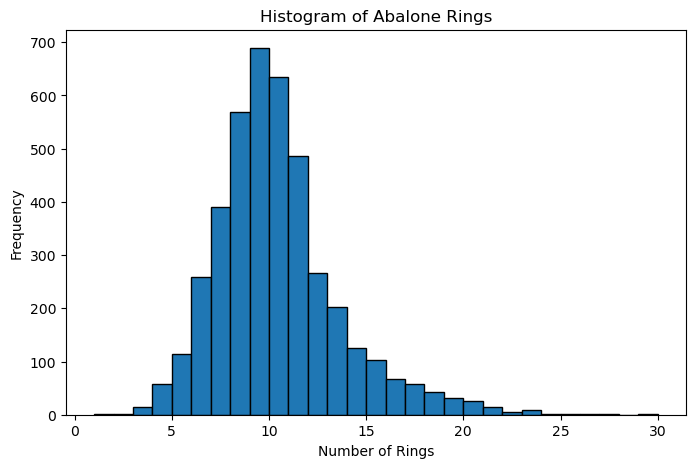

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(
    df["rings"],
    bins=range(df["rings"].min(), df["rings"].max() + 2),
    edgecolor="black"
)

plt.xlabel("Number of Rings")
plt.ylabel("Frequency")
plt.title("Histogram of Abalone Rings")

plt.show()

In [17]:
df["rings"].std()

3.2241690320681133

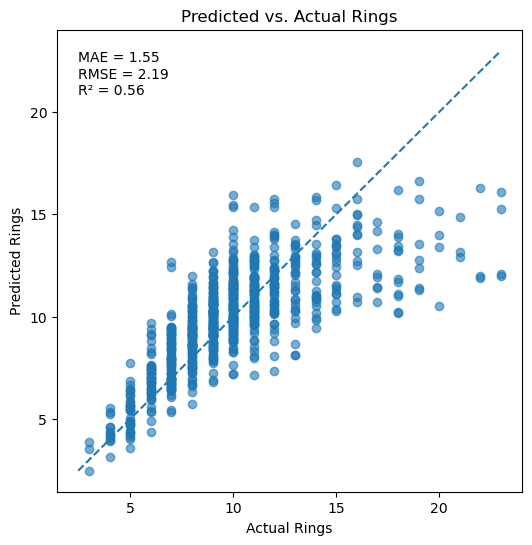

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Predicted vs. Actual Rings")

plt.text(
    min_value,
    max_value,
    f"MAE = {mae:.2f}\nRMSE = {rmse:.2f}\nR² = {r2:.2f}",
    verticalalignment="top"
)

plt.show()

In [20]:
best_model.named_steps["model"].feature_importances_

array([0.07742797, 0.1039252 , 0.14575321, 0.14040893, 0.13687225,
       0.09976665, 0.26907415, 0.01768192, 0.00908972])

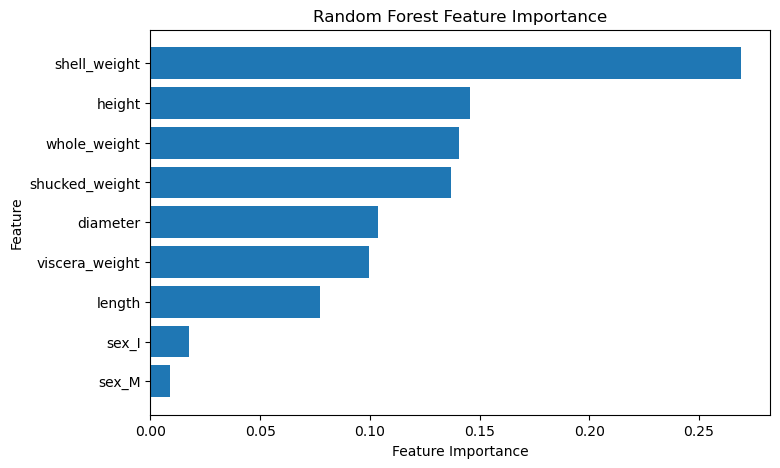

In [23]:
importances = best_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()